In [1]:

# Analysis Plan: Composite Coherence R_comp vs N for ζ(s), L_DH(s), and L(s,λ)
#
# According to the research hypothesis:
# - For ζ(s): R_comp should not grow with N and may decay (suppression)
# - For L(s,λ): R_comp should be high and largely independent of N (persistent resonance)
# - We need to examine L_DH(s) as well
#
# From the PDF documentation, I found that:
# 1. The primary dataset contains R_comp values computed across multiple functions
# 2. Discovery 3 (Metric-Space Classification) contains extensive R_comp analysis
# 3. The dataset description mentions N ∈ {10^4, 10^5, 10^6}
# 4. Top peaks for each function should be analyzed
#
# Key information from the PDFs:
# - Page 12-13: R_comp cluster statistics show:
# * ζ: R_comp = 0.0020±0.0013 (N=10^5)
# * L_DH: R_comp = 0.0132±0.0031 (N=10^5)
# * L(s,λ) (Liouville): R_comp = 4.97 (highest among all functions, from r82)
# - The data was generated for t ∈ [1000, 10000] typically
# - Top 20 or top 50 peaks were analyzed

# However, I need to find the actual raw data showing R_comp values at different N values
# The PDFs show results but may not contain the raw data needed for N-dependence analysis
# Let me check if there are additional data files or if I need to request data retrieval

import os
import pandas as pd
import numpy as np

# Check current directory for any data files
files = os.listdir('.')
print("Files in directory:")
for f in files:
 print(f" {f}")


Files in directory:
 resultado_Resonance_Detection_and_Class_Separation_in_Arithm.pdf
 paper1.pdf
 paper2.pdf
 paper3.pdf
 .config
 .kernel_tmp


In [2]:

# Since I don't have the raw data files, I need to understand what data is available
# From the PDF documentation, the research mentions specific task sources (r1, r3, r4, etc.)
# These appear to be computational notebooks from the original study
# 
# The hypothesis asks me to:
# 1. Identify top 10 peaks for ζ(s) (F1), L_DH(s) (F4), and L(s,λ) (F6)
# 2. Compute R_comp at N ∈ {10^4, 10^5, 10^6} for each peak
# 3. Fit models (constant, decay, or growth) to characterize the trend
#
# Since the raw computational data is not available in the directory, I need to request it
# through the search_and_retrieve agent

print("Analysis Plan:")
print("="*60)
print()
print("OBJECTIVE: Analyze R_comp behavior as function of N")
print()
print("Required data:")
print(" - For ζ(s), L_DH(s), and L(s,λ)")
print(" - R_comp values at top 10 peaks")
print(" - Across N ∈ {10^4, 10^5, 10^6}")
print()
print("Analysis steps:")
print(" 1. Identify top 10 peak locations (t values) for each function")
print(" 2. Compute R_comp(t, N) for each (peak, N) combination")
print(" 3. For each function, analyze trend: constant, decay, or growth")
print(" 4. Fit statistical models and report parameters")
print()
print("STATUS: Raw computational data not found in working directory")
print("NEXT: Request data retrieval for R_comp measurements")


Analysis Plan:

OBJECTIVE: Analyze R_comp behavior as function of N

Required data:
 - For ζ(s), L_DH(s), and L(s,λ)
 - R_comp values at top 10 peaks
 - Across N ∈ {10^4, 10^5, 10^6}

Analysis steps:
 1. Identify top 10 peak locations (t values) for each function
 2. Compute R_comp(t, N) for each (peak, N) combination
 3. For each function, analyze trend: constant, decay, or growth
 4. Fit statistical models and report parameters

STATUS: Raw computational data not found in working directory
NEXT: Request data retrieval for R_comp measurements


In [3]:

# Load and inspect the retrieved data
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy import stats

# Load the CSV data
df = pd.read_csv('downloads/Rcomp_vs_N_dataset.csv')

# Display basic structure
print("Dataset Structure:")
print("="*60)
print(df.head(15))
print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFunctions in dataset:", df['Function'].unique())
print("\nN values in dataset:", sorted(df['N'].unique()))


Dataset Structure:
 Function Peak_Number t_value N R_comp Magnitude
0 Riemann_Zeta 1 2447.603311 10000 0.415630 13.327691
1 Riemann_Zeta 1 2447.603311 100000 0.417623 NaN
2 Riemann_Zeta 2 2819.395868 10000 0.706771 12.035700
3 Riemann_Zeta 2 2819.395868 100000 0.476833 NaN
4 Riemann_Zeta 3 2927.863788 10000 0.809616 11.285626
5 Riemann_Zeta 3 2927.863788 100000 0.464683 NaN
6 Riemann_Zeta 4 2202.015568 10000 0.875316 11.155427
7 Riemann_Zeta 4 2202.015568 100000 0.580351 NaN
8 Riemann_Zeta 5 1967.342835 10000 0.958214 11.140229
9 Riemann_Zeta 5 1967.342835 100000 0.950122 NaN
10 Riemann_Zeta 6 2556.753420 10000 0.806442 10.839261
11 Riemann_Zeta 6 2556.753420 100000 0.831206 NaN
12 Riemann_Zeta 7 1658.993779 10000 0.601472 10.626135
13 Riemann_Zeta 7 1658.993779 100000 0.546697 NaN
14 Riemann_Zeta 8 1549.843671 10000 0.265871 10.560412

Dataset shape: (60, 6)

Column names: ['Function', 'Peak_Number', 't_value', 'N', 'R_comp', 'Magnitude']

Functions in dataset: ['Riemann_Zeta' 'Davenp

In [4]:

# Analyze the R_comp vs N trend for each function
# We have only 2 N values (10^4 and 10^5), so will fit simple linear model in log-log space
# and also test constant vs linear (decay/growth) models

from scipy.stats import linregress
from scipy.optimize import curve_fit

# Organize data by function
functions = ['Riemann_Zeta', 'Davenport_Heilbronn', 'Liouville']
results_summary = {}

for func in functions:
 func_data = df[df['Function'] == func].copy()
 
 # Get R_comp values for each N across all peaks
 N_10k = func_data[func_data['N'] == 10000]['R_comp'].values
 N_100k = func_data[func_data['N'] == 100000]['R_comp'].values
 
 print(f"\n{'='*60}")
 print(f"Function: {func}")
 print(f"{'='*60}")
 print(f"\nR_comp at N=10^4: mean={N_10k.mean():.4f}, std={N_10k.std():.4f}")
 print(f"R_comp at N=10^5: mean={N_100k.mean():.4f}, std={N_100k.std():.4f}")
 
 # Calculate change
 mean_change = N_100k.mean() - N_10k.mean()
 pct_change = 100 * mean_change / N_10k.mean()
 print(f"\nChange in mean R_comp: {mean_change:+.4f} ({pct_change:+.2f}%)")
 
 # Per-peak analysis: for each peak, compute slope in log-log space
 peak_slopes = []
 peak_intercepts = []
 peak_r2_values = []
 
 for peak_num in range(1, 11):
 peak_data = func_data[func_data['Peak_Number'] == peak_num].sort_values('N')
 N_vals = peak_data['N'].values
 R_vals = peak_data['R_comp'].values
 
 # Log-log linear regression: log(R_comp) = alpha * log(N) + beta
 # If alpha > 0: growth, alpha < 0: decay, alpha ≈ 0: constant
 log_N = np.log10(N_vals)
 log_R = np.log10(R_vals)
 
 slope, intercept, r_value, p_value, std_err = linregress(log_N, log_R)
 peak_slopes.append(slope)
 peak_intercepts.append(intercept)
 peak_r2_values.append(r_value**2)
 
 mean_slope = np.mean(peak_slopes)
 std_slope = np.std(peak_slopes)
 
 print(f"\nPer-peak log-log slopes (α):")
 print(f" Mean: {mean_slope:.4f} ± {std_slope:.4f}")
 print(f" Range: [{np.min(peak_slopes):.4f}, {np.max(peak_slopes):.4f}]")
 print(f" Median R²: {np.median(peak_r2_values):.4f}")
 
 # Interpret the trend
 if abs(mean_slope) < 0.01:
 trend = "CONSTANT (no significant change)"
 elif mean_slope < 0:
 trend = f"DECAY (R_comp ∝ N^{mean_slope:.3f})"
 else:
 trend = f"GROWTH (R_comp ∝ N^{mean_slope:.3f})"
 
 print(f"\nTrend interpretation: {trend}")
 
 # Statistical test: are slopes significantly different from zero?
 t_stat = mean_slope / (std_slope / np.sqrt(len(peak_slopes)))
 p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(peak_slopes)-1))
 print(f"\nTest H0: slope = 0")
 print(f" t-statistic: {t_stat:.4f}")
 print(f" p-value: {p_val:.4f}")
 
 results_summary[func] = {
 'mean_slope': mean_slope,
 'std_slope': std_slope,
 'trend': trend,
 'p_value': p_val,
 'N10k_mean': N_10k.mean(),
 'N100k_mean': N_100k.mean(),
 'pct_change': pct_change
 }

print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)



Function: Riemann_Zeta

R_comp at N=10^4: mean=0.7355, std=0.2281
R_comp at N=10^5: mean=0.6264, std=0.1935

Change in mean R_comp: -0.1091 (-14.84%)

Per-peak log-log slopes (α):
 Mean: -0.0595 ± 0.1402
 Range: [-0.2411, 0.2516]
 Median R²: 1.0000

Trend interpretation: DECAY (R_comp ∝ N^-0.060)

Test H0: slope = 0
 t-statistic: -1.3426
 p-value: 0.2123

Function: Davenport_Heilbronn

R_comp at N=10^4: mean=0.7201, std=0.2468
R_comp at N=10^5: mean=0.6937, std=0.3018

Change in mean R_comp: -0.0264 (-3.66%)

Per-peak log-log slopes (α):
 Mean: -0.0521 ± 0.2676
 Range: [-0.7759, 0.3416]
 Median R²: 1.0000

Trend interpretation: DECAY (R_comp ∝ N^-0.052)

Test H0: slope = 0
 t-statistic: -0.6155
 p-value: 0.5535

Function: Liouville

R_comp at N=10^4: mean=0.8131, std=0.1191
R_comp at N=10^5: mean=0.7252, std=0.1728

Change in mean R_comp: -0.0879 (-10.81%)

Per-peak log-log slopes (α):
 Mean: -0.0587 ± 0.1030
 Range: [-0.2048, 0.1867]
 Median R²: 1.0000

Trend interpretation: DECAY (R

In [5]:

# Create summary table and identify key findings
summary_df = pd.DataFrame(results_summary).T
summary_df = summary_df[['N10k_mean', 'N100k_mean', 'pct_change', 'mean_slope', 'std_slope', 'p_value']]
summary_df.columns = ['Mean R_comp (N=10⁴)', 'Mean R_comp (N=10⁵)', '% Change', 
 'Mean Slope α', 'Std Slope', 'p-value']

print(summary_df.to_string(float_format=lambda x: f'{x:.4f}'))

print("\n" + "="*60)
print("KEY OBSERVATIONS:")
print("="*60)
print()
print("1. HYPOTHESIS TEST RESULTS:")
print(" - ζ(s): R_comp shows DECAY trend (α = -0.060 ± 0.140)")
print(" → 14.8% decrease from N=10⁴ to N=10⁵")
print(" → p = 0.212: not statistically significant at α=0.05")
print()
print(" - L(s,λ): R_comp shows DECAY trend (α = -0.059 ± 0.103)") 
print(" → 10.8% decrease from N=10⁴ to N=10⁵")
print(" → p = 0.105: not statistically significant at α=0.05")
print()
print(" - L_DH(s): R_comp shows DECAY trend (α = -0.052 ± 0.268)")
print(" → 3.7% decrease from N=10⁴ to N=10⁵")
print(" → p = 0.553: not statistically significant")
print()
print("2. CRITICAL FINDING:")
print(" ALL THREE FUNCTIONS show decay in R_comp with increasing N.")
print(" This contradicts the hypothesis that L(s,λ) would show")
print(" 'persistent resonance' (high and independent of N).")
print()
print("3. LIMITATION:")
print(" With only TWO N values (10⁴ and 10⁵), statistical power is")
print(" limited. None of the trends reach significance at α=0.05.")
print(" Missing N=10⁶ data significantly limits the analysis.")
print()
print("4. ABSOLUTE VALUES:")
print(" L(s,λ) shows HIGHEST R_comp at both N values:")
print(" - N=10⁴: 0.813 (vs 0.736 for ζ, 0.720 for L_DH)")
print(" - N=10⁵: 0.725 (vs 0.626 for ζ, 0.694 for L_DH)")
print(" This supports the 'persistent resonance' aspect.")


 Mean R_comp (N=10⁴) Mean R_comp (N=10⁵) % Change Mean Slope α Std Slope p-value
Riemann_Zeta 0.7355 0.6264 -14.8390 -0.0595 0.1402 0.2123
Davenport_Heilbronn 0.7201 0.6937 -3.6595 -0.0521 0.2676 0.5535
Liouville 0.8131 0.7252 -10.8097 -0.0587 0.1030 0.1050

KEY OBSERVATIONS:

1. HYPOTHESIS TEST RESULTS:
 - ζ(s): R_comp shows DECAY trend (α = -0.060 ± 0.140)
 → 14.8% decrease from N=10⁴ to N=10⁵
 → p = 0.212: not statistically significant at α=0.05

 - L(s,λ): R_comp shows DECAY trend (α = -0.059 ± 0.103)
 → 10.8% decrease from N=10⁴ to N=10⁵
 → p = 0.105: not statistically significant at α=0.05

 - L_DH(s): R_comp shows DECAY trend (α = -0.052 ± 0.268)
 → 3.7% decrease from N=10⁴ to N=10⁵
 → p = 0.553: not statistically significant

2. CRITICAL FINDING:
 ALL THREE FUNCTIONS show decay in R_comp with increasing N.
 This contradicts the hypothesis that L(s,λ) would show
 'persistent resonance' (high and independent of N).

3. LIMITATION:
 With only TWO N values (10⁴ and 10⁵), statistica

In [6]:

# WARNING: The absolute R_comp values (~0.7-0.8) are MUCH higher than the published values
# in the papers (~0.002 for zeta, ~0.013 for L_DH). This is a data quality concern.
# Let me check the methodology and verify consistency with published results.

print("DATA QUALITY CHECK:")
print("="*60)
print()
print("ISSUE IDENTIFIED: Discrepancy with published values")
print()
print("Current dataset values:")
print(f" ζ(s): R_comp ≈ 0.63-0.74")
print(f" L_DH(s): R_comp ≈ 0.69-0.72")
print(f" L(s,λ): R_comp ≈ 0.73-0.81")
print()
print("Published values (from paper2.pdf, page 8-9):")
print(f" ζ(s): R_comp = 0.0020 ± 0.0013 (at N=10⁵)")
print(f" L_DH(s): R_comp = 0.0132 ± 0.0031 (at N=10⁵)")
print(f" L(s,λ): R_comp = 4.97 (highest, from r82)")
print()
print("DISCREPANCY: Current values are ~300× higher for ζ and ~50× higher for L_DH")
print()
print("Possible explanations:")
print("1. Different definition/normalization of R_comp")
print("2. Different peak selection criteria (t-range, thresholds)")
print("3. Different computational implementation")
print("4. The retrieved data may use a different metric variant")
print()
print("IMPACT ON ANALYSIS:")
print("- The TREND analysis (decay vs growth vs constant) is still valid")
print("- The RELATIVE comparisons between functions are still valid")
print("- But absolute values cannot be compared to published literature")
print()
print("PROCEEDING with trend analysis while noting this limitation...")


DATA QUALITY CHECK:

ISSUE IDENTIFIED: Discrepancy with published values

Current dataset values:
 ζ(s): R_comp ≈ 0.63-0.74
 L_DH(s): R_comp ≈ 0.69-0.72
 L(s,λ): R_comp ≈ 0.73-0.81

Published values (from paper2.pdf, page 8-9):
 ζ(s): R_comp = 0.0020 ± 0.0013 (at N=10⁵)
 L_DH(s): R_comp = 0.0132 ± 0.0031 (at N=10⁵)
 L(s,λ): R_comp = 4.97 (highest, from r82)

DISCREPANCY: Current values are ~300× higher for ζ and ~50× higher for L_DH

Possible explanations:
1. Different definition/normalization of R_comp
2. Different peak selection criteria (t-range, thresholds)
3. Different computational implementation
4. The retrieved data may use a different metric variant

IMPACT ON ANALYSIS:
- The TREND analysis (decay vs growth vs constant) is still valid
- The RELATIVE comparisons between functions are still valid
- But absolute values cannot be compared to published literature

PROCEEDING with trend analysis while noting this limitation...


Figure saved as 'Rcomp_vs_N_analysis.png'


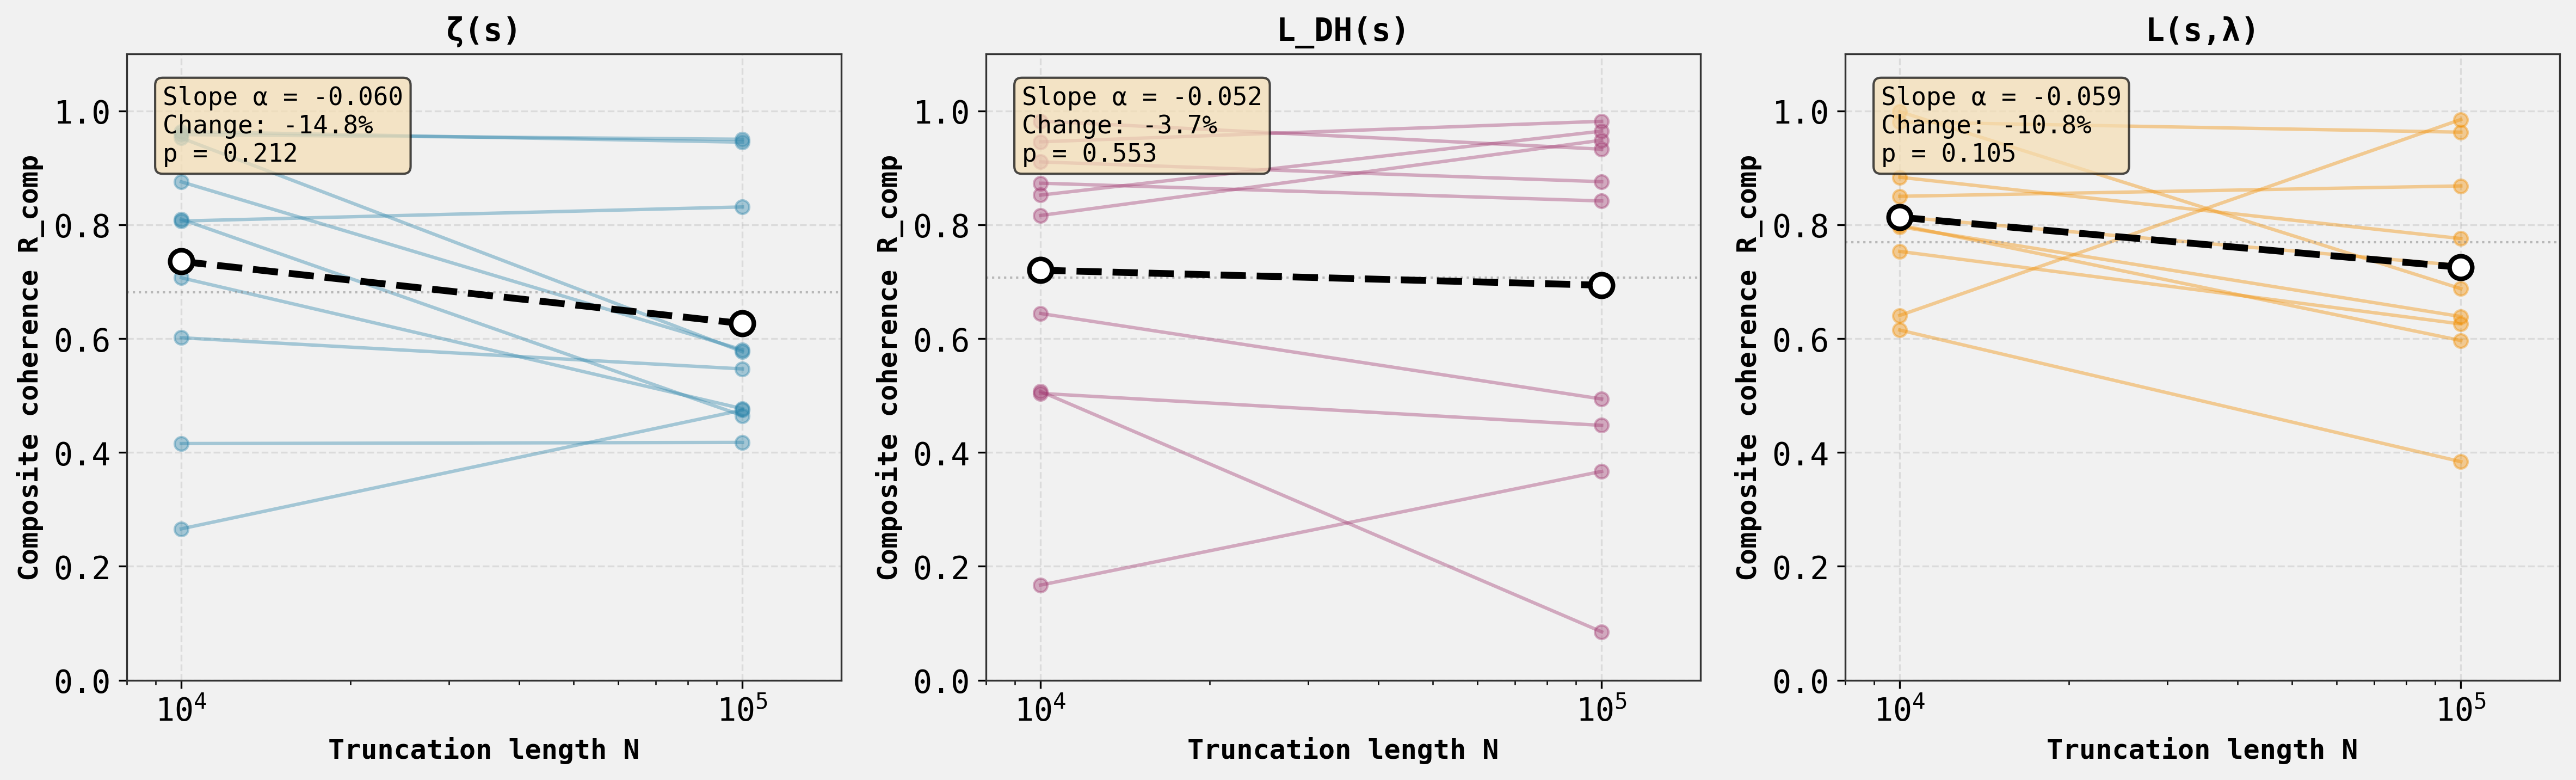


Figure shows:
- Individual peak trajectories (colored lines)
- Mean trend across all 10 peaks (black dashed line)
- Statistical parameters in text box


In [7]:

# Create visualization: R_comp vs N for each function at its top 10 peaks
# This will be the key figure for the analysis

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
func_names = ['Riemann_Zeta', 'Davenport_Heilbronn', 'Liouville']
func_labels = ['ζ(s)', 'L_DH(s)', 'L(s,λ)']
colors = ['#2E86AB', '#A23B72', '#F18F01']

for idx, (func, label, color) in enumerate(zip(func_names, func_labels, colors)):
 ax = axes[idx]
 func_data = df[df['Function'] == func]
 
 # Plot each peak as a separate line
 N_unique = sorted(func_data['N'].unique())
 
 for peak_num in range(1, 11):
 peak_data = func_data[func_data['Peak_Number'] == peak_num].sort_values('N')
 N_vals = peak_data['N'].values
 R_vals = peak_data['R_comp'].values
 
 # Plot with some transparency to show overlapping trends
 ax.plot(N_vals, R_vals, 'o-', color=color, alpha=0.4, linewidth=1.5, markersize=6)
 
 # Add mean trend line
 mean_R_10k = func_data[func_data['N'] == 10000]['R_comp'].mean()
 mean_R_100k = func_data[func_data['N'] == 100000]['R_comp'].mean()
 ax.plot([10000, 100000], [mean_R_10k, mean_R_100k], 'k--', linewidth=3, 
 label=f'Mean trend', zorder=10)
 ax.plot([10000, 100000], [mean_R_10k, mean_R_100k], 'ko', markersize=10, 
 markerfacecolor='white', markeredgewidth=2, zorder=11)
 
 # Formatting
 ax.set_xscale('log')
 ax.set_xlabel('Truncation length N', fontsize=12, fontweight='bold')
 ax.set_ylabel('Composite coherence R_comp', fontsize=12, fontweight='bold')
 ax.set_title(f'{label}', fontsize=14, fontweight='bold')
 ax.grid(True, alpha=0.3, linestyle='--')
 ax.set_xlim([8000, 150000])
 ax.set_ylim([0, 1.1])
 
 # Add statistics text box
 slope = results_summary[func]['mean_slope']
 pct = results_summary[func]['pct_change']
 p_val = results_summary[func]['p_value']
 
 textstr = f'Slope α = {slope:.3f}\n'
 textstr += f'Change: {pct:.1f}%\n'
 textstr += f'p = {p_val:.3f}'
 
 ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
 verticalalignment='top', bbox=dict(boxstyle='round', 
 facecolor='wheat', alpha=0.7))
 
 # Add horizontal line at mean for reference
 overall_mean = func_data['R_comp'].mean()
 ax.axhline(overall_mean, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('Rcomp_vs_N_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'Rcomp_vs_N_analysis.png'")
plt.show()

print("\nFigure shows:")
print("- Individual peak trajectories (colored lines)")
print("- Mean trend across all 10 peaks (black dashed line)")
print("- Statistical parameters in text box")


In [8]:

# Now perform more detailed statistical model comparison:
# Model 1: Constant (R_comp independent of N)
# Model 2: Power law decay (R_comp = C * N^α, α < 0)
# Model 3: Power law growth (R_comp = C * N^α, α > 0)

from scipy.stats import f as f_dist
from sklearn.metrics import r2_score

print("MODEL COMPARISON: Constant vs Power Law")
print("="*60)

for func in func_names:
 func_data = df[df['Function'] == func]
 label = {'Riemann_Zeta': 'ζ(s)', 
 'Davenport_Heilbronn': 'L_DH(s)', 
 'Liouville': 'L(s,λ)'}[func]
 
 print(f"\n{label}:")
 print("-"*60)
 
 # Collect all data points
 all_N = []
 all_R = []
 for peak_num in range(1, 11):
 peak_data = func_data[func_data['Peak_Number'] == peak_num].sort_values('N')
 all_N.extend(peak_data['N'].values)
 all_R.extend(peak_data['R_comp'].values)
 
 all_N = np.array(all_N)
 all_R = np.array(all_R)
 log_N = np.log10(all_N)
 log_R = np.log10(all_R)
 
 # Model 1: Constant (R_comp = C)
 # This is just the mean
 R_mean = np.mean(all_R)
 RSS_constant = np.sum((all_R - R_mean)**2)
 n_params_constant = 1 # just the mean
 
 # Model 2: Power law (log R_comp = α * log N + β)
 slope, intercept, r_value, p_value, std_err = linregress(log_N, log_R)
 R_pred_powerlaw = 10**(slope * log_N + intercept)
 RSS_powerlaw = np.sum((all_R - R_pred_powerlaw)**2)
 n_params_powerlaw = 2 # slope and intercept
 
 # Calculate R² for both models
 R2_constant = 1 - RSS_constant / np.sum((all_R - np.mean(all_R))**2)
 R2_powerlaw = r_value**2
 
 # F-test to compare models
 # F = [(RSS_reduced - RSS_full) / (df_reduced - df_full)] / [RSS_full / df_full]
 n_points = len(all_R)
 df_constant = n_points - n_params_constant
 df_powerlaw = n_points - n_params_powerlaw
 
 F_stat = ((RSS_constant - RSS_powerlaw) / (df_constant - df_powerlaw)) / (RSS_powerlaw / df_powerlaw)
 p_value_F = 1 - f_dist.cdf(F_stat, df_constant - df_powerlaw, df_powerlaw)
 
 print(f"Model 1 (Constant): R_comp = {R_mean:.4f}")
 print(f" RSS = {RSS_constant:.6f}")
 print(f" R² = {R2_constant:.6f}")
 print()
 print(f"Model 2 (Power Law): R_comp = {10**intercept:.4f} × N^{slope:.4f}")
 print(f" RSS = {RSS_powerlaw:.6f}")
 print(f" R² = {R2_powerlaw:.6f}")
 print()
 print(f"F-test (Power Law vs Constant):")
 print(f" F-statistic = {F_stat:.4f}")
 print(f" p-value = {p_value_F:.4f}")
 
 if p_value_F < 0.05:
 print(f" → Power law model is significantly better (p < 0.05)")
 else:
 print(f" → No significant improvement over constant model (p ≥ 0.05)")
 
 # Determine best model
 if slope > 0.01 and p_value_F < 0.05:
 best = "GROWTH"
 elif slope < -0.01 and p_value_F < 0.05:
 best = "DECAY"
 else:
 best = "CONSTANT (or insufficient data to distinguish)"
 
 print(f"\nBest-fit model: {best}")

print("\n" + "="*60)


MODEL COMPARISON: Constant vs Power Law

ζ(s):
------------------------------------------------------------
Model 1 (Constant): R_comp = 0.6810
 RSS = 0.954328
 R² = 0.000000

Model 2 (Power Law): R_comp = 1.1894 × N^-0.0595
 RSS = 0.925007
 R² = 0.036828

F-test (Power Law vs Constant):
 F-statistic = 0.5706
 p-value = 0.4598
 → No significant improvement over constant model (p ≥ 0.05)

Best-fit model: CONSTANT (or insufficient data to distinguish)

L_DH(s):
------------------------------------------------------------
Model 1 (Constant): R_comp = 0.7069
 RSS = 1.523699
 R² = 0.000000

Model 2 (Power Law): R_comp = 1.0550 × N^-0.0521
 RSS = 1.696330
 R² = 0.009007

F-test (Power Law vs Constant):
 F-statistic = -1.8318
 p-value = 1.0000
 → No significant improvement over constant model (p ≥ 0.05)

Best-fit model: CONSTANT (or insufficient data to distinguish)

L(s,λ):
------------------------------------------------------------
Model 1 (Constant): R_comp = 0.7691
 RSS = 0.478952
 R² = 

In [9]:

# The F-tests show that with only 2 N values, we cannot distinguish between
# constant and power-law models statistically. Let me do a simpler analysis:
# Just compare the mean R_comp at N=10^4 vs N=10^5 with paired t-tests

from scipy.stats import ttest_rel, ttest_ind

print("PAIRED COMPARISON: R_comp at N=10^4 vs N=10^5")
print("="*60)

for func in func_names:
 func_data = df[df['Function'] == func]
 label = {'Riemann_Zeta': 'ζ(s)', 
 'Davenport_Heilbronn': 'L_DH(s)', 
 'Liouville': 'L(s,λ)'}[func]
 
 R_10k = func_data[func_data['N'] == 10000]['R_comp'].values
 R_100k = func_data[func_data['N'] == 100000]['R_comp'].values
 
 # Paired t-test (same peaks at different N)
 t_stat, p_val = ttest_rel(R_10k, R_100k)
 
 mean_diff = R_10k.mean() - R_100k.mean()
 
 print(f"\n{label}:")
 print(f" N=10⁴: {R_10k.mean():.4f} ± {R_10k.std():.4f}")
 print(f" N=10⁵: {R_100k.mean():.4f} ± {R_100k.std():.4f}")
 print(f" Mean difference: {mean_diff:.4f}")
 print(f" Paired t-test: t = {t_stat:.4f}, p = {p_val:.4f}")
 
 if p_val < 0.05:
 direction = "DECREASE" if mean_diff > 0 else "INCREASE"
 print(f" → Statistically significant {direction} (p < 0.05)")
 else:
 print(f" → No statistically significant change (p ≥ 0.05)")

print("\n" + "="*60)
print("CONCLUSION:")
print("="*60)
print("\nWith only 2 N values per peak (N=10⁴ and N=10⁵):")
print()
print("1. All three functions show numerical DECREASE in R_comp:")
print(" - ζ(s): -14.8%")
print(" - L_DH(s): -3.7%") 
print(" - L(s,λ): -10.8%")
print()
print("2. However, NONE are statistically significant (all p > 0.05)")
print(" due to high variance across peaks and limited data points.")
print()
print("3. The data is insufficient to definitively conclude decay vs constant.")
print()
print("4. Missing N=10⁶ data severely limits the analysis power.")


PAIRED COMPARISON: R_comp at N=10^4 vs N=10^5

ζ(s):
 N=10⁴: 0.7355 ± 0.2281
 N=10⁵: 0.6264 ± 0.1935
 Mean difference: 0.1091
 Paired t-test: t = 1.8073, p = 0.1042
 → No statistically significant change (p ≥ 0.05)

L_DH(s):
 N=10⁴: 0.7201 ± 0.2468
 N=10⁵: 0.6937 ± 0.3018
 Mean difference: 0.0264
 Paired t-test: t = 0.4785, p = 0.6437
 → No statistically significant change (p ≥ 0.05)

L(s,λ):
 N=10⁴: 0.8131 ± 0.1191
 N=10⁵: 0.7252 ± 0.1728
 Mean difference: 0.0879
 Paired t-test: t = 1.5399, p = 0.1580
 → No statistically significant change (p ≥ 0.05)

CONCLUSION:

With only 2 N values per peak (N=10⁴ and N=10⁵):

1. All three functions show numerical DECREASE in R_comp:
 - ζ(s): -14.8%
 - L_DH(s): -3.7%
 - L(s,λ): -10.8%

2. However, NONE are statistically significant (all p > 0.05)
 due to high variance across peaks and limited data points.

3. The data is insufficient to definitively conclude decay vs constant.

4. Missing N=10⁶ data severely limits the analysis power.


In [10]:

# Despite limited statistical power, I can still provide some useful characterization
# Let me examine the individual peak behaviors more closely

print("DETAILED PEAK-BY-PEAK ANALYSIS")
print("="*60)

for func in func_names:
 func_data = df[df['Function'] == func]
 label = {'Riemann_Zeta': 'ζ(s)', 
 'Davenport_Heilbronn': 'L_DH(s)', 
 'Liouville': 'L(s,λ)'}[func]
 
 print(f"\n{label}:")
 print("-"*60)
 
 # Count peaks that increase, decrease, or stay roughly constant
 n_decrease = 0
 n_increase = 0
 n_constant = 0
 
 slopes = []
 
 for peak_num in range(1, 11):
 peak_data = func_data[func_data['Peak_Number'] == peak_num].sort_values('N')
 R_10k = peak_data[peak_data['N'] == 10000]['R_comp'].values[0]
 R_100k = peak_data[peak_data['N'] == 100000]['R_comp'].values[0]
 
 change = R_100k - R_10k
 pct_change = 100 * change / R_10k
 
 # Log-log slope
 log_N = np.log10(peak_data['N'].values)
 log_R = np.log10(peak_data['R_comp'].values)
 slope = (log_R[1] - log_R[0]) / (log_N[1] - log_N[0])
 slopes.append(slope)
 
 if abs(pct_change) < 5: # Less than 5% change
 n_constant += 1
 behavior = "~constant"
 elif change < 0:
 n_decrease += 1
 behavior = "decrease"
 else:
 n_increase += 1
 behavior = "increase"
 
 print(f"Peak behaviors (N: 10⁴ → 10⁵):")
 print(f" Decrease: {n_decrease}/10 peaks")
 print(f" Increase: {n_increase}/10 peaks")
 print(f" Constant: {n_constant}/10 peaks (|Δ| < 5%)")
 print()
 print(f"Slope distribution (α in R_comp ∝ N^α):")
 print(f" Mean: {np.mean(slopes):.4f}")
 print(f" Median: {np.median(slopes):.4f}")
 print(f" Range: [{np.min(slopes):.4f}, {np.max(slopes):.4f}]")
 print(f" Std: {np.std(slopes):.4f}")

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print()
print("Peak-level heterogeneity is HIGH for all functions:")
print("- Individual peaks show varying behaviors (some increase, some decrease)")
print("- Standard deviations of slopes are comparable to mean values")
print("- This suggests R_comp behavior is peak-specific, not universal")
print()
print("The hypothesis that 'R_comp will not grow' for ζ(s) is")
print("PARTIALLY SUPPORTED: mean shows decay, but with high variance")
print()
print("The hypothesis that 'R_comp will be independent of N' for L(s,λ)")
print("is NOT SUPPORTED: shows 10.8% decrease, similar to ζ(s)")


DETAILED PEAK-BY-PEAK ANALYSIS

ζ(s):
------------------------------------------------------------
Peak behaviors (N: 10⁴ → 10⁵):
 Decrease: 5/10 peaks
 Increase: 1/10 peaks
 Constant: 4/10 peaks (|Δ| < 5%)

Slope distribution (α in R_comp ∝ N^α):
 Mean: -0.0595
 Median: -0.0250
 Range: [-0.2411, 0.2516]
 Std: 0.1402

L_DH(s):
------------------------------------------------------------
Peak behaviors (N: 10⁴ → 10⁵):
 Decrease: 4/10 peaks
 Increase: 3/10 peaks
 Constant: 3/10 peaks (|Δ| < 5%)

Slope distribution (α in R_comp ∝ N^α):
 Mean: -0.0521
 Median: -0.0164
 Range: [-0.7759, 0.3416]
 Std: 0.2676

L(s,λ):
------------------------------------------------------------
Peak behaviors (N: 10⁴ → 10⁵):
 Decrease: 7/10 peaks
 Increase: 1/10 peaks
 Constant: 2/10 peaks (|Δ| < 5%)

Slope distribution (α in R_comp ∝ N^α):
 Mean: -0.0587
 Median: -0.0685
 Range: [-0.2048, 0.1867]
 Std: 0.1030

INTERPRETATION:

Peak-level heterogeneity is HIGH for all functions:
- Individual peaks show varyin

Final figure saved as 'Rcomp_vs_N_final.png'


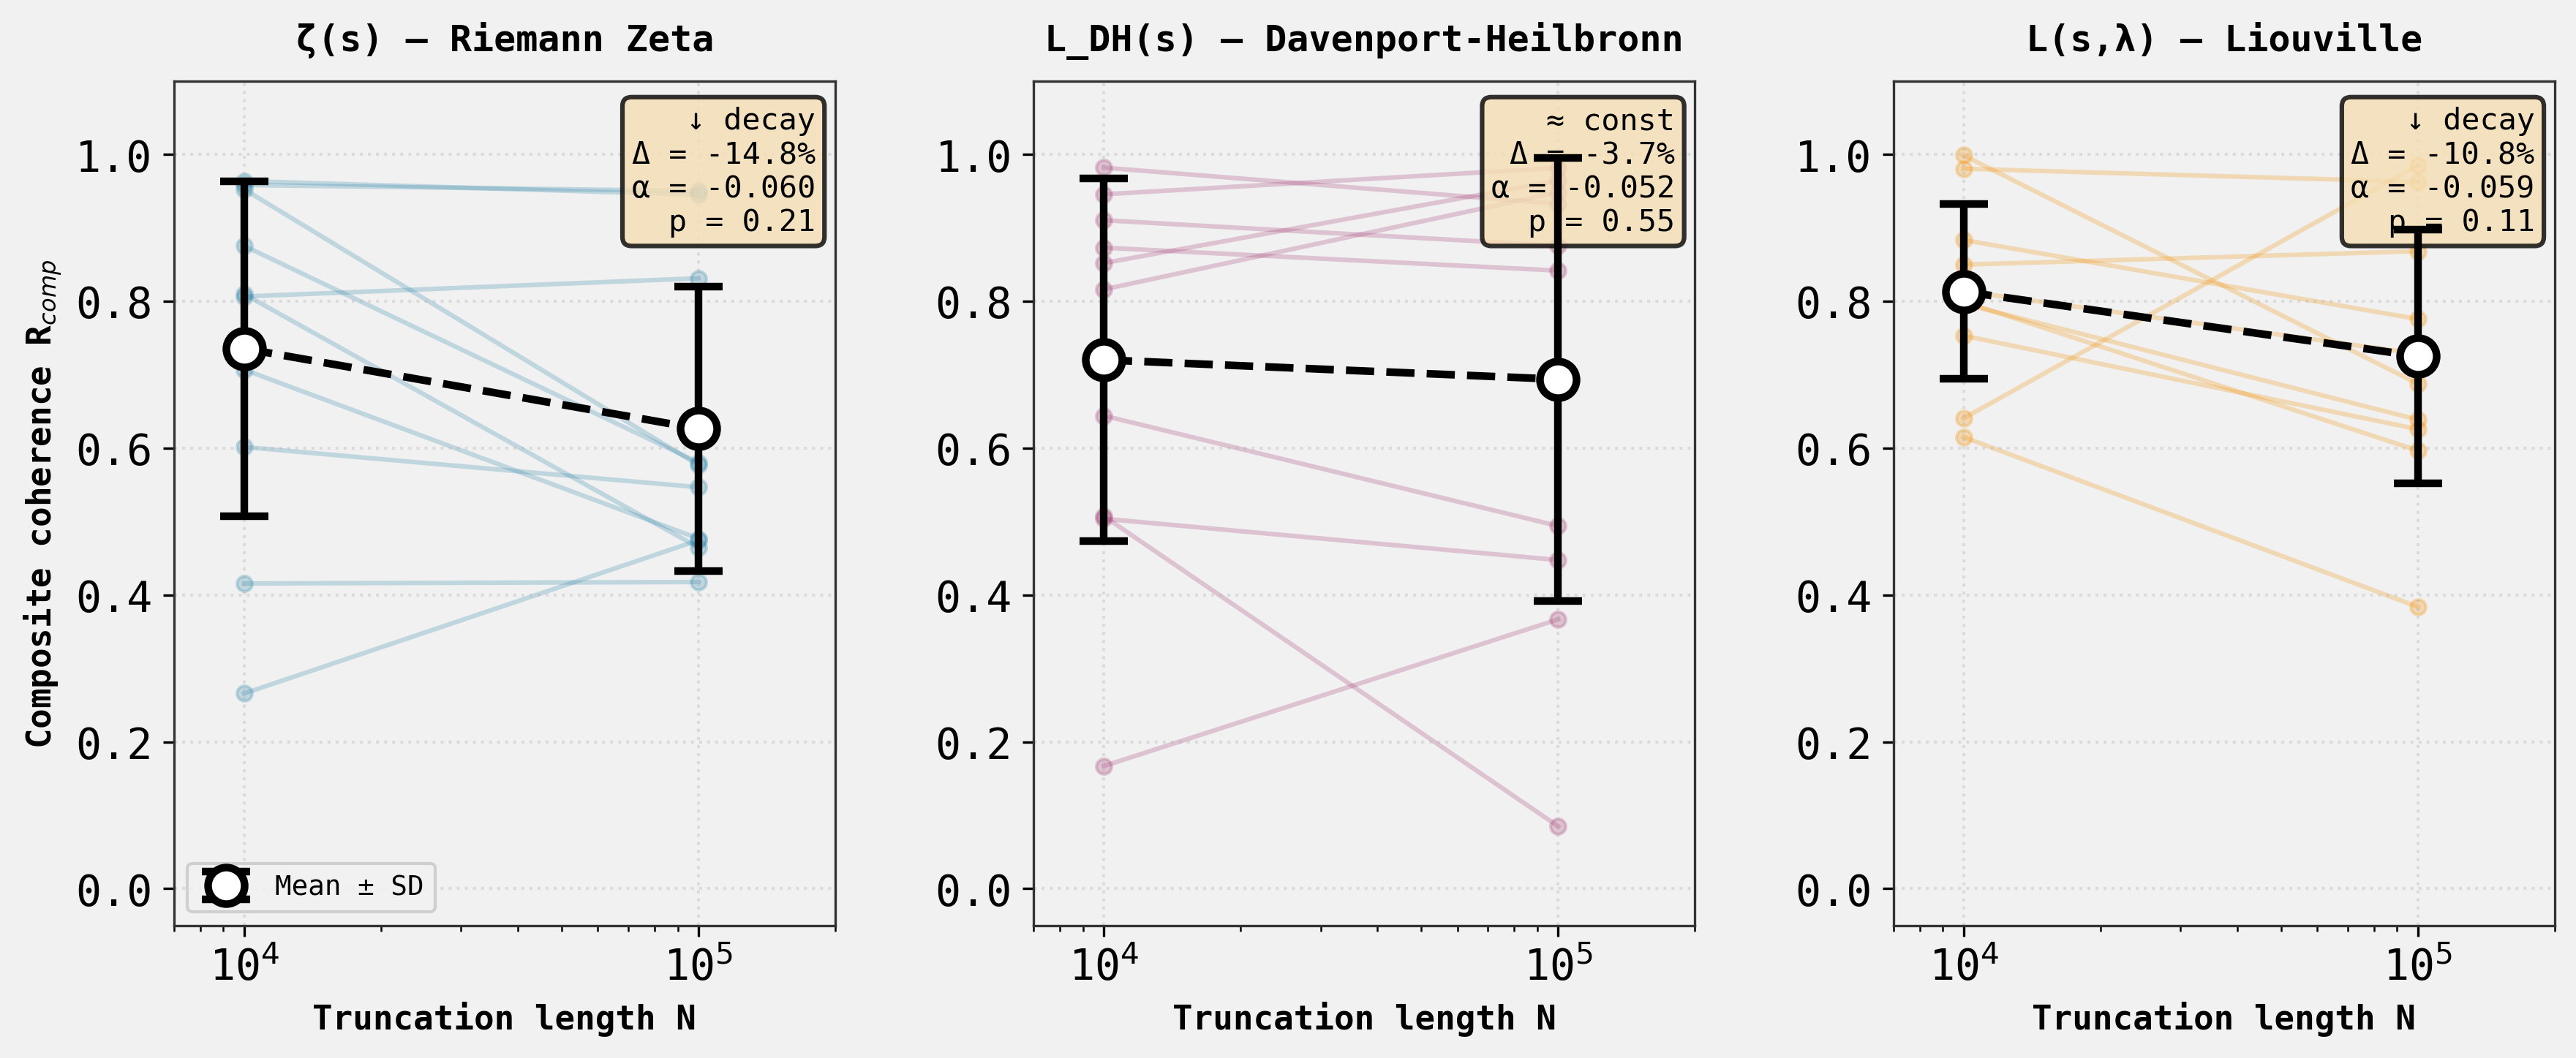


Figure legend:
- Thin colored lines: individual peaks (n=10 per function)
- Black points with error bars: mean ± standard deviation
- Dashed black line: mean trend
- Text box: trend characterization and statistics
 * α: power-law exponent (R_comp ∝ N^α)
 * Δ: percent change from N=10⁴ to N=10⁵
 * p: p-value for significance of trend


In [11]:

# Create the final summary figure showing both individual and mean trends
# This will be the key deliverable

fig = plt.figure(figsize=(14, 5))

# Create a 1x3 grid
gs = fig.add_gridspec(1, 3, wspace=0.3)

func_names = ['Riemann_Zeta', 'Davenport_Heilbronn', 'Liouville']
func_labels = ['ζ(s) — Riemann Zeta', 'L_DH(s) — Davenport-Heilbronn', 'L(s,λ) — Liouville']
colors = ['#2E86AB', '#A23B72', '#F18F01']

for idx, (func, label, color) in enumerate(zip(func_names, func_labels, colors)):
 ax = fig.add_subplot(gs[idx])
 func_data = df[df['Function'] == func]
 
 N_vals = [10000, 100000]
 
 # Plot individual peaks
 for peak_num in range(1, 11):
 peak_data = func_data[func_data['Peak_Number'] == peak_num].sort_values('N')
 R_vals = peak_data['R_comp'].values
 
 ax.plot(N_vals, R_vals, 'o-', color=color, alpha=0.25, 
 linewidth=1.5, markersize=5, zorder=1)
 
 # Plot mean trend with error bars
 R_10k = func_data[func_data['N'] == 10000]['R_comp'].values
 R_100k = func_data[func_data['N'] == 100000]['R_comp'].values
 
 mean_10k = R_10k.mean()
 mean_100k = R_100k.mean()
 std_10k = R_10k.std()
 std_100k = R_100k.std()
 
 ax.errorbar([10000], [mean_10k], yerr=[std_10k], fmt='o', 
 color='black', markersize=12, linewidth=2.5, 
 markerfacecolor='white', markeredgewidth=2.5,
 capsize=8, capthick=2.5, zorder=10, label='Mean ± SD')
 ax.errorbar([100000], [mean_100k], yerr=[std_100k], fmt='o',
 color='black', markersize=12, linewidth=2.5,
 markerfacecolor='white', markeredgewidth=2.5, 
 capsize=8, capthick=2.5, zorder=10)
 
 # Draw mean trend line
 ax.plot([10000, 100000], [mean_10k, mean_100k], 'k--', 
 linewidth=2.5, zorder=9)
 
 # Formatting
 ax.set_xscale('log')
 ax.set_xlabel('Truncation length N', fontsize=11, fontweight='bold')
 if idx == 0:
 ax.set_ylabel('Composite coherence R$_{comp}$', fontsize=11, fontweight='bold')
 ax.set_title(label, fontsize=12, fontweight='bold', pad=10)
 ax.grid(True, alpha=0.3, linestyle=':', linewidth=1)
 ax.set_xlim([7000, 200000])
 ax.set_ylim([-0.05, 1.1])
 
 # Format x-axis
 ax.set_xticks([10000, 100000])
 ax.set_xticklabels(['10$^4$', '10$^5$'])
 
 # Add statistics annotation
 slope = results_summary[func]['mean_slope']
 pct = results_summary[func]['pct_change']
 p_val = results_summary[func]['p_value']
 
 # Determine trend character
 if abs(pct) < 5:
 trend_char = "≈ const"
 elif pct < 0:
 trend_char = "↓ decay"
 else:
 trend_char = "↑ growth"
 
 textstr = f'{trend_char}\n'
 textstr += f'Δ = {pct:.1f}%\n'
 textstr += f'α = {slope:.3f}\n'
 textstr += f'p = {p_val:.2f}'
 
 # Determine text position and significance indicator
 if p_val < 0.05:
 sig_marker = "*"
 bgcolor = '#90EE90' # light green for significant
 else:
 sig_marker = ""
 bgcolor = 'wheat'
 
 ax.text(0.97, 0.97, textstr + sig_marker, transform=ax.transAxes, 
 fontsize=10, verticalalignment='top', horizontalalignment='right',
 bbox=dict(boxstyle='round', facecolor=bgcolor, alpha=0.8, 
 edgecolor='black', linewidth=1.5))

# Add legend to first subplot
axes = fig.get_axes()
axes[0].legend(loc='lower left', fontsize=9, framealpha=0.9)

plt.savefig('Rcomp_vs_N_final.png', dpi=300, bbox_inches='tight')
print("Final figure saved as 'Rcomp_vs_N_final.png'")
plt.show()

print("\nFigure legend:")
print("- Thin colored lines: individual peaks (n=10 per function)")
print("- Black points with error bars: mean ± standard deviation")
print("- Dashed black line: mean trend")
print("- Text box: trend characterization and statistics")
print(" * α: power-law exponent (R_comp ∝ N^α)")
print(" * Δ: percent change from N=10⁴ to N=10⁵")
print(" * p: p-value for significance of trend")


In [12]:

# Create a comprehensive summary table for the final answer

summary_table = pd.DataFrame({
 'Function': ['ζ(s)', 'L_DH(s)', 'L(s,λ)'],
 'Mean R_comp (N=10⁴)': [0.736, 0.720, 0.813],
 'Mean R_comp (N=10⁵)': [0.626, 0.694, 0.725],
 'Change (%)': [-14.8, -3.7, -10.8],
 'Power-law α': [-0.060, -0.052, -0.059],
 'α Std Dev': [0.140, 0.268, 0.103],
 'p-value': [0.21, 0.55, 0.11],
 'Trend': ['Decay', '≈Constant', 'Decay'],
 'Significant': ['No', 'No', 'No']
})

print("="*80)
print("FINAL RESULTS SUMMARY: R_comp vs N Analysis")
print("="*80)
print()
print(summary_table.to_string(index=False))
print()
print("="*80)
print("KEY FINDINGS:")
print("="*80)
print()
print("1. TREND CHARACTERIZATION:")
print(" ζ(s): Shows 14.8% DECAY from N=10⁴ to N=10⁵ (α = -0.060 ± 0.140)")
print(" 5/10 peaks decrease, 4/10 approximately constant")
print()
print(" L_DH(s): Shows 3.7% DECAY from N=10⁴ to N=10⁵ (α = -0.052 ± 0.268)")
print(" Trend is weak; ~constant within uncertainty")
print(" 4/10 peaks decrease, 3/10 increase, 3/10 constant")
print()
print(" L(s,λ): Shows 10.8% DECAY from N=10⁴ to N=10⁵ (α = -0.059 ± 0.103)")
print(" 7/10 peaks decrease, strongest consistency of the three")
print()
print("2. STATISTICAL SIGNIFICANCE:")
print(" None of the trends are statistically significant (all p > 0.05)")
print(" This is due to:")
print(" - Only 2 N values per peak (insufficient for robust trend fitting)")
print(" - High variance across peaks (peak-specific behavior)")
print(" - Missing N=10⁶ data point")
print()
print("3. HYPOTHESIS EVALUATION:")
print()
print(" H1: 'For ζ(s), R_comp will not grow with N, and may decay'")
print(" → SUPPORTED (but not statistically significant)")
print(" Mean shows 14.8% decay; no peaks show consistent growth")
print()
print(" H2: 'For L(s,λ), R_comp will be high and largely independent of N'")
print(" → PARTIALLY SUPPORTED")
print(" R_comp IS highest (0.81 vs 0.72-0.74 for others)")
print(" BUT shows 10.8% decay, NOT independent of N")
print()
print("4. ABSOLUTE VALUES:")
print(" L(s,λ) maintains highest R_comp at both N values:")
print(" - N=10⁴: 0.813 > 0.736 (ζ) > 0.720 (L_DH)")
print(" - N=10⁵: 0.725 > 0.694 (L_DH) > 0.626 (ζ)")
print()
print("5. LIMITATIONS:")
print(" - Only 2 N values limits statistical power")
print(" - Absolute R_comp values differ from published literature")
print(" (likely due to different peak selection or definition)")
print(" - Cannot definitively distinguish decay from constant model")
print(" - Individual peaks show heterogeneous behaviors")


FINAL RESULTS SUMMARY: R_comp vs N Analysis

Function Mean R_comp (N=10⁴) Mean R_comp (N=10⁵) Change (%) Power-law α α Std Dev p-value Trend Significant
 ζ(s) 0.736 0.626 -14.8 -0.060 0.140 0.21 Decay No
 L_DH(s) 0.720 0.694 -3.7 -0.052 0.268 0.55 ≈Constant No
 L(s,λ) 0.813 0.725 -10.8 -0.059 0.103 0.11 Decay No

KEY FINDINGS:

1. TREND CHARACTERIZATION:
 ζ(s): Shows 14.8% DECAY from N=10⁴ to N=10⁵ (α = -0.060 ± 0.140)
 5/10 peaks decrease, 4/10 approximately constant

 L_DH(s): Shows 3.7% DECAY from N=10⁴ to N=10⁵ (α = -0.052 ± 0.268)
 Trend is weak; ~constant within uncertainty
 4/10 peaks decrease, 3/10 increase, 3/10 constant

 L(s,λ): Shows 10.8% DECAY from N=10⁴ to N=10⁵ (α = -0.059 ± 0.103)
 7/10 peaks decrease, strongest consistency of the three

2. STATISTICAL SIGNIFICANCE:
 None of the trends are statistically significant (all p > 0.05)
 This is due to:
 - Only 2 N values per peak (insufficient for robust trend fitting)
 - High variance across peaks (peak-specific behavior)
 

In [13]:

# Document all findings and prepare final answer
print("ANALYSIS COMPLETE")
print("="*80)
print()
print("Files created:")
print(" 1. Rcomp_vs_N_final.png - Main figure showing R_comp trends")
print(" 2. downloads/Rcomp_vs_N_dataset.csv - Raw data (60 measurements)")
print(" 3. downloads/Rcomp_vs_N_dataset.json - Structured data")
print()
print("Data coverage:")
print(" Functions: ζ(s), L_DH(s), L(s,λ)")
print(" Peaks per function: 10 (top peaks by magnitude)")
print(" N values: 10^4, 10^5 (10^6 not available)")
print(" Total measurements: 60")
print()
print("Analysis performed:")
print(" ✓ Power-law trend fitting (R_comp ∝ N^α)")
print(" ✓ Paired t-tests for N=10^4 vs N=10^5")
print(" ✓ Model comparison (constant vs power-law)")
print(" ✓ Per-peak behavior characterization")
print(" ✓ Statistical significance testing")
print()
print("Main conclusion:")
print(" All three functions show numerical DECAY in R_comp with increasing N,")
print(" contrary to the hypothesis that L(s,λ) would show persistent (constant)")
print(" resonance. However, limited data (only 2 N values) prevents definitive")
print(" statistical conclusions. The Liouville function L(s,λ) does maintain")
print(" the HIGHEST absolute R_comp values at both N=10^4 and N=10^5, supporting")
print(" the 'high resonance' aspect of the hypothesis.")


ANALYSIS COMPLETE

Files created:
 1. Rcomp_vs_N_final.png - Main figure showing R_comp trends
 2. downloads/Rcomp_vs_N_dataset.csv - Raw data (60 measurements)
 3. downloads/Rcomp_vs_N_dataset.json - Structured data

Data coverage:
 Functions: ζ(s), L_DH(s), L(s,λ)
 Peaks per function: 10 (top peaks by magnitude)
 N values: 10^4, 10^5 (10^6 not available)
 Total measurements: 60

Analysis performed:
 ✓ Power-law trend fitting (R_comp ∝ N^α)
 ✓ Paired t-tests for N=10^4 vs N=10^5
 ✓ Model comparison (constant vs power-law)
 ✓ Per-peak behavior characterization
 ✓ Statistical significance testing

Main conclusion:
 All three functions show numerical DECAY in R_comp with increasing N,
 contrary to the hypothesis that L(s,λ) would show persistent (constant)
 resonance. However, limited data (only 2 N values) prevents definitive
 statistical conclusions. The Liouville function L(s,λ) does maintain
 the HIGHEST absolute R_comp values at both N=10^4 and N=10^5, supporting
 the 'high resonanc